# Returning booster, part 5: imperfect sensing and state estimation

Parts 1–4 of this series gave the MPC oracle access to the booster's true state—the closed loop received $\mathbf{x}(t)$ directly from the integrator. Real boosters do not have that luxury. They carry an inertial measurement unit (IMU) that drifts, a radar altimeter that updates ten times per second, and a GPS receiver that reports a few-metre fix once per second. A *state estimator* fuses these noisy, multi-rate streams into the single state estimate $\hat{\mathbf{x}}(t)$ that the MPC actually uses.

This part wires that picture: plant → sensors → EKF → MPC → plant. We quantify how much performance is lost compared to the truth-state baseline of Part 3, and we sweep sensor-noise scales to map the boundary at which the controller stops landing the booster softly. The goal is not a beautiful result—truth-state Part-3 already produced one—but an honest one: estimation error couples directly into terminal residuals, and the architecture must absorb that fact rather than hide it.

**Reading time:** ≈30 minutes. **Runtime on CPU:** ≈4–7 minutes (one closed-loop sim plus a three-point robustness sweep).

## Prerequisites

- **Part 1** (booster dynamics) and **Part 2** (open-loop trajopt + NMPC tracking).
- **Part 3** (atmosphere, grid fins, multi-phase dispatcher, IPOPT monkey-patch) — we inherit the full multi-phase plant, the BBB / aero-glide / MPC controllers, and the dispatcher block from there.
- Familiarity with the Kalman filter (predict / correct) and with the Jaxonomy `LeafSystem` API. The [Jaxonomy Kalman tutorial](state_estimation_with_Kalman_filters.ipynb) covers both.

## The artifact: a Falcon-9-class booster with realistic avionics

The plant is unchanged from Part 3: 13-state booster, 5-input actuation (throttle, two gimbal angles, two grid-fin deflections), atmosphere with exponential density, grid fins with $C_{L,\delta}=4\,/\text{rad}$. The mission is the multi-phase descent from a 9 km / 4 km-downrange apogee, executed by the same BBB / aero-glide / MPC dispatcher.

What changes is the **feedback path**. We instrument the plant with three sensors:

| Sensor | What it measures | Noise (1σ) | Bias model | Rate |
| :-- | :-- | --: | :-- | --: |
| IMU — accelerometer | specific force $\mathbf{a}_b\in\mathbb{R}^3$ in body frame | $0.05~\text{m/s}^2$ per axis | random walk, $\sigma_b=10^{-3}~\text{m/s}^2/\sqrt{\text{s}}$ | 50 Hz |
| IMU — gyro | body angular rate $\boldsymbol{\omega}\in\mathbb{R}^3$ | $0.001~\text{rad/s}$ per axis | random walk, $\sigma_b=10^{-5}~\text{rad/s}/\sqrt{\text{s}}$ | 50 Hz |
| Radar altimeter | altitude $z$ | $0.5~\text{m}$ | none | 10 Hz |
| GPS | position $(x,y,z)$ | $3~\text{m}$ per axis | none | 1 Hz |

(Orders of magnitude follow tactical-grade IMU and consumer-GPS spec sheets; see the references at the end.) The estimator runs an EKF at 25 Hz with the *Part-1-class* simplified dynamics model — i.e. no aero, no grid fins. The mismatch between the estimator's model and the high-fidelity plant is deliberate; it is the *normal* case in aerospace practice and a useful pedagogical pressure on the EKF.

## Imports and physical constants

In [1]:
# Standard scientific Python
import time as time_mod
import numpy as np
import matplotlib.pyplot as plt

# JAX with float64 — EKF Jacobians and trajopt need the precision
from jax import config
config.update("jax_enable_x64", True)
import jax
import jax.numpy as jnp

# Jaxonomy
import jaxonomy
from jaxonomy.framework import LeafSystem
from jaxonomy.library import (
    LookupTable1d,
    SourceBlock,
    ExtendedKalmanFilter,
)
from jaxonomy.diagnostics import analyze_saturation, analyze_phase_activity
from jaxonomy import logging as jx_logging
jx_logging.set_log_level(jx_logging.ERROR)

RNG_SEED = 0
np.random.seed(RNG_SEED)

## Inherited code from Part 3

We re-define the plant, controllers, and dispatcher here in a single block. The code is verbatim from Part 3 (with the BBB-guard fix from v18 and the pitch-sign-corrected attitude PD from v8); refer to that notebook for the design discussion. The only addition is a thin observation function `g_simplified(x, u)` used by the EKF below.

In [2]:
# ---- Physical constants (inherited from Parts 1–3) -----------------------
M_DRY = 25_000.0; M_FUEL_0 = 12_000.0
T_MAX = 800_000.0; ETA_MIN = 0.4; ETA_MAX = 1.0
ISP = 280.0; G0 = 9.80665; G = 9.81
DELTA_MAX = np.deg2rad(10.0)
L_BOOSTER = 40.0; R_BOOSTER = 1.85

# Atmosphere + aero
RHO_0 = 1.225; H_SCALE = 8500.0
GAMMA_AIR = 1.4; R_GAS = 287.05; T_ATM = 288.15
A_REF = np.pi * R_BOOSTER**2
MACH_BREAKS = np.array([0.0, 0.3, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0, 3.0, 5.0])
CD_VALUES   = np.array([0.82, 0.82, 0.85, 0.90, 1.10, 1.15, 1.10, 0.95, 0.80, 0.70])
CN_ALPHA = 2.5
L_COM_TO_CP = 2.0

S_FIN = 4.0; CL_DELTA_FIN = 4.0
DELTA_FIN_MAX = np.deg2rad(20.0)
L_FIN_FROM_COM = 18.0

def cylinder_inertia(m, L, r):
    Ixx = Iyy = m * (3 * r**2 + L**2) / 12.0
    Izz = 0.5 * m * r**2
    return Ixx, Iyy, Izz
IXX0, IYY0, IZZ0 = cylinder_inertia(M_DRY + M_FUEL_0, L_BOOSTER, R_BOOSTER)

def rho_air(z):
    return RHO_0 * jnp.exp(-jnp.maximum(z, 0.0) / H_SCALE)
def speed_of_sound(_z):
    return jnp.sqrt(GAMMA_AIR * R_GAS * T_ATM)

# Build the Cd lookup so we can verify it exists; not used in the rhs functions below,
# which use jnp.interp directly for autodiff smoothness.
cd_block = LookupTable1d(MACH_BREAKS, CD_VALUES, "linear", name="cd_vs_mach")
print(f"Atmosphere & aero constants loaded; rho(0)={float(rho_air(0.0)):.3f} kg/m^3")

Atmosphere & aero constants loaded; rho(0)=1.225 kg/m^3


In [3]:
# ---- Plant dynamics (Part 3) --------------------------------------------
def euler_zyx_kinematics_inv(phi, theta):
    cphi, sphi = jnp.cos(phi), jnp.sin(phi)
    cth, sth = jnp.cos(theta), jnp.sin(theta)
    tth = sth / cth
    return jnp.array([
        [1.0, sphi*tth,   cphi*tth],
        [0.0, cphi,      -sphi    ],
        [0.0, sphi/cth,   cphi/cth],
    ])

def _R_wb(phi, theta, psi):
    cphi, sphi = jnp.cos(phi), jnp.sin(phi)
    cth,  sth  = jnp.cos(theta), jnp.sin(theta)
    cpsi, spsi = jnp.cos(psi), jnp.sin(psi)
    return jnp.array([
        [cpsi*cth, cpsi*sth*sphi - spsi*cphi, cpsi*sth*cphi + spsi*sphi],
        [spsi*cth, spsi*sth*sphi + cpsi*cphi, spsi*sth*cphi - cpsi*sphi],
        [-sth,     cth*sphi,                   cth*cphi                ],
    ])

def aero_forces_and_moments(state, fin_pitch, fin_yaw):
    pos = state[0:3]; vel = state[3:6]
    phi, theta, psi = state[6:9]
    z = pos[2]
    rho = rho_air(z); a_s = speed_of_sound(z)
    R_wb = _R_wb(phi, theta, psi)
    V = jnp.linalg.norm(vel) + 1e-6
    v_B = R_wb.T @ vel
    mach = V / a_s
    q_dyn = 0.5 * rho * V**2
    Cd = jnp.interp(mach, jnp.asarray(MACH_BREAKS), jnp.asarray(CD_VALUES))
    F_drag_W = -Cd * A_REF * q_dyn * (vel / V)
    alpha_y = -v_B[0] / V; alpha_x = -v_B[1] / V
    F_normal_B = q_dyn * A_REF * CN_ALPHA * jnp.array([alpha_y, alpha_x, 0.0])
    F_normal_W = R_wb @ F_normal_B
    r_cp = jnp.array([0.0, 0.0, L_COM_TO_CP])
    tau_normal_B = jnp.cross(r_cp, F_normal_B)
    F_fin_B = 2.0 * q_dyn * S_FIN * CL_DELTA_FIN * jnp.array([fin_pitch, fin_yaw, 0.0])
    F_fin_W = R_wb @ F_fin_B
    r_fin = jnp.array([0.0, 0.0, L_FIN_FROM_COM])
    tau_fin_B = jnp.cross(r_fin, F_fin_B)
    F_aero_W = F_drag_W + F_normal_W + F_fin_W
    tau_aero_B = tau_normal_B + tau_fin_B
    F_aero_W = jnp.where(z > 0.0, F_aero_W, jnp.zeros(3))
    tau_aero_B = jnp.where(z > 0.0, tau_aero_B, jnp.zeros(3))
    return F_aero_W, tau_aero_B, q_dyn, mach

def booster_trajopt_rhs(state, control,
                        m_dry=M_DRY, T_max=T_MAX, isp=ISP, g0=G0, g=G,
                        L=L_BOOSTER, Ixx=IXX0, Iyy=IYY0, Izz=IZZ0):
    """Part-1 simplified booster: 3-vec control (throttle, gimbal_y, gimbal_z). No aero."""
    pos = state[0:3]; vel = state[3:6]
    eta_a = state[6:9]; omega = state[9:12]; m_f = state[12]
    eta_throttle, delta_y, delta_z = control
    phi, theta, psi = eta_a
    m_total = m_dry + jnp.maximum(m_f, 0.0)
    R_wb = _R_wb(phi, theta, psi)
    F_B = eta_throttle * T_max * jnp.array([jnp.sin(delta_y), -jnp.sin(delta_z),
                                             jnp.cos(delta_y) * jnp.cos(delta_z)])
    F_thrust_W = R_wb @ F_B
    G_W = jnp.array([0.0, 0.0, -m_total * g])
    acc = (F_thrust_W + G_W) / m_total
    tau_B = jnp.array([-(L/2.0)*eta_throttle*T_max*jnp.sin(delta_z),
                       -(L/2.0)*eta_throttle*T_max*jnp.sin(delta_y), 0.0])
    I_diag = jnp.array([Ixx, Iyy, Izz])
    omega_dot = (tau_B - jnp.cross(omega, I_diag * omega)) / I_diag
    eta_dot = euler_zyx_kinematics_inv(phi, theta) @ omega
    m_f_dot = jnp.where(m_f > 0.0, -eta_throttle * T_max / (isp * g0), 0.0)
    return jnp.concatenate([vel, acc, eta_dot, omega_dot, jnp.array([m_f_dot])])

def booster_full_rhs(state, control,
                     m_dry=M_DRY, T_max=T_MAX, isp=ISP, g0=G0, g=G,
                     L=L_BOOSTER, Ixx=IXX0, Iyy=IYY0, Izz=IZZ0):
    """Part-3 truth plant: simplified rhs + aero/fins. 5-vec control."""
    pos = state[0:3]; vel = state[3:6]
    eta_a = state[6:9]; omega = state[9:12]; m_f = state[12]
    eta_throttle, delta_y, delta_z, fin_pitch, fin_yaw = control
    phi, theta, psi = eta_a
    m_total = m_dry + jnp.maximum(m_f, 0.0)
    R_wb = _R_wb(phi, theta, psi)
    F_B = eta_throttle * T_max * jnp.array([jnp.sin(delta_y), -jnp.sin(delta_z),
                                             jnp.cos(delta_y) * jnp.cos(delta_z)])
    F_thrust_W = R_wb @ F_B
    G_W = jnp.array([0.0, 0.0, -m_total * g])
    F_aero_W, tau_aero_B, _q, _M = aero_forces_and_moments(state, fin_pitch, fin_yaw)
    acc = (F_thrust_W + G_W + F_aero_W) / m_total
    tau_thrust_B = jnp.array([-(L/2.0)*eta_throttle*T_max*jnp.sin(delta_z),
                              -(L/2.0)*eta_throttle*T_max*jnp.sin(delta_y), 0.0])
    tau_total_B = tau_thrust_B + tau_aero_B
    I_diag = jnp.array([Ixx, Iyy, Izz])
    omega_dot = (tau_total_B - jnp.cross(omega, I_diag * omega)) / I_diag
    eta_dot = euler_zyx_kinematics_inv(phi, theta) @ omega
    m_f_dot = jnp.where(m_f > 0.0, -eta_throttle * T_max / (isp * g0), 0.0)
    return jnp.concatenate([vel, acc, eta_dot, omega_dot, jnp.array([m_f_dot])])

class BoosterFull(LeafSystem):
    """Truth plant for Part 5: identical to Part-3 BoosterFull."""
    def __init__(self, x0=None, name="booster_full"):
        super().__init__(name=name)
        if x0 is None:
            x0 = jnp.zeros(13)
        self.declare_input_port(name="u")
        self.declare_continuous_state(default_value=jnp.array(x0), ode=self.ode)
        self.declare_continuous_state_output(name="x")
    def ode(self, time, state, *inputs, **params):
        return booster_full_rhs(state.continuous_state, inputs[0])

print("Plant + dynamics inherited from Part 3.")

Plant + dynamics inherited from Part 3.


In [4]:
# ---- Controllers and dispatcher (Part 3, verbatim) ----------------------
K_X_GLIDE = 2.0e-4
K_V_GLIDE = 6.0e-3
BBB_TILT_TARGET = jnp.deg2rad(-30.0)
ETA_BBB = 0.5

def _wrap_to_pi(angle):
    return (angle + jnp.pi) % (2.0 * jnp.pi) - jnp.pi

def boost_back_controller(state, eta_bbb=ETA_BBB):
    eta_a = state[6:9]; omega = state[9:12]
    K_p_att = 0.5; K_d_att = 0.5
    theta_err = _wrap_to_pi(eta_a[1] - BBB_TILT_TARGET)
    phi_err   = _wrap_to_pi(eta_a[0])
    delta_y_cmd = jnp.clip( K_p_att * theta_err + K_d_att * omega[1], -DELTA_MAX, DELTA_MAX)
    delta_z_cmd = jnp.clip( K_p_att * phi_err   + K_d_att * omega[0], -DELTA_MAX, DELTA_MAX)
    return jnp.array([eta_bbb, delta_y_cmd, delta_z_cmd, 0.0, 0.0])

def aero_glide_controller(state):
    pos = state[0:3]; vel = state[3:6]; omega = state[9:12]; eta_a = state[6:9]
    K_x = K_X_GLIDE; K_v = K_V_GLIDE
    theta_target = jnp.clip( K_x * pos[0] + K_v * vel[0], -jnp.deg2rad(15.0), jnp.deg2rad(15.0))
    phi_target   = jnp.clip(-K_x * pos[1] - K_v * vel[1], -jnp.deg2rad(15.0), jnp.deg2rad(15.0))
    K_p = 0.50; K_d = 0.20
    pitch_err = _wrap_to_pi(eta_a[1] - theta_target)
    phi_err   = _wrap_to_pi(eta_a[0] - phi_target)
    fin_pitch_cmd = jnp.clip(-K_p * pitch_err - K_d * omega[1], -DELTA_FIN_MAX, DELTA_FIN_MAX)
    fin_yaw_cmd   = jnp.clip( K_p * phi_err   + K_d * omega[0], -DELTA_FIN_MAX, DELTA_FIN_MAX)
    return jnp.array([0.0, 0.0, 0.0, fin_pitch_cmd, fin_yaw_cmd])

Z_LANDING_TRIGGER = 1500.0
T_BBB_MAX = 15.0

class MultiPhaseDispatcher(LeafSystem):
    """Single-leaf dispatcher (Part-3 v18). Reads ESTIMATED state — not truth."""
    def __init__(self, name="dispatcher"):
        super().__init__(name=name)
        self.declare_input_port(name="x_hat")
        self.declare_input_port(name="u_mpc")

        def _phase(time, state, *inputs, **parameters):
            x_hat, _u_mpc = inputs
            z = x_hat[2]
            # Time-gate the state-based transition: the EKF output port's
            # default value is zero before the first periodic update fires,
            # so a raw `z < trigger` check would fire phase 2 at t=0 from a
            # transient zero. Requiring `time > T_BBB_MAX` ensures BBB and
            # glide phases have a chance to run before landing-burn dispatch.
            in_landing = (z < Z_LANDING_TRIGGER) & (time > T_BBB_MAX)
            bbb_active = (~in_landing) & (time < T_BBB_MAX)
            phase = jnp.where(in_landing, 2, jnp.where(bbb_active, 0, 1))
            return phase.astype(jnp.float64)

        def _output(time, state, *inputs, **parameters):
            x_hat, u_mpc = inputs
            phase = _phase(time, state, *inputs, **parameters)
            phase_int = jnp.clip(jnp.round(phase).astype(jnp.int32), 0, 2)
            u_land5 = jnp.concatenate([u_mpc, jnp.zeros(2)])
            return jax.lax.switch(phase_int,
                [lambda: boost_back_controller(x_hat),
                 lambda: aero_glide_controller(x_hat),
                 lambda: u_land5])

        self.declare_output_port(_output, name="u",
                                  default_value=jnp.zeros(5), requires_inputs=True)
        self.declare_output_port(_phase, name="phase",
                                  default_value=jnp.array(0.0), requires_inputs=True)

print("Controllers (BBB, glide) and dispatcher loaded. Dispatcher input port 0 "
      "reads the ESTIMATED state x_hat (Part 5's key change).")

Controllers (BBB, glide) and dispatcher loaded. Dispatcher input port 0 reads the ESTIMATED state x_hat (Part 5's key change).


## Sensor models

We model three sensors as a single bundled `LeafSystem` whose output port emits a 10-vector measurement at 50 Hz:

$$
\mathbf{y} = \begin{bmatrix}
\mathbf{a}_{b,\text{meas}} & (3)\\
\boldsymbol{\omega}_{\text{meas}} & (3)\\
z_{\text{rad}} & (1)\\
\mathbf{p}_{\text{gps}} & (3)
\end{bmatrix}\in\mathbb{R}^{10}.
\tag{1}
$$

Each block of the vector is corrupted by:

$$
\mathbf{y}_i = h_i(\mathbf{x},\mathbf{u}) + \mathbf{b}_i + \boldsymbol{\nu}_i,\qquad \boldsymbol{\nu}_i\sim\mathcal{N}(\mathbf{0},\sigma_i^2 I),\quad \mathbf{b}_i\overset{\text{r.w.}}{\sim}\mathcal{N}(\mathbf{b}_i,\sigma_{b,i}^2 \Delta t\, I).
\tag{2}
$$

Slow IMU bias drift dominates the IMU error budget over a 60-second mission; the per-axis $1\sigma$ random-walk increment over 60 s is $\sigma_b\sqrt{60}\approx 7.7\times10^{-3}$ m/s² (accel) and $7.7\times10^{-5}$ rad/s (gyro). The low-rate sensors (radar 10 Hz, GPS 1 Hz) update on their own clocks; between updates the held value is constant, which is the standard zero-order-hold behaviour an EKF sees from an asynchronous sensor.

**Dimensional check.** Accelerometer noise PSD is $0.05\,\text{m/s}^2/\sqrt{\text{Hz}}$ at 50 Hz, so per-sample variance is $(0.05)^2\cdot 50 = 0.125\,\text{(m/s}^2)^2$, i.e. $1\sigma\approx0.35\,\text{m/s}^2$ per sample. We will use a more aggressive per-sample $\sigma=0.05\,\text{m/s}^2$ directly (interpreted as already-band-limited spec) so the comparison with truth-state stays interpretable.

### Why bundle?

A single bundled sensor is the simplest way to give the EKF a single fixed-size measurement vector at a single rate. The alternative — one `LeafSystem` per sensor plus an aggregator — is more realistic but adds two layers of plumbing without changing the math. We mention the trade-off and pick the simple option.

In [5]:
# ---- Nominal sensor parameters ------------------------------------------
SENSOR_DT = 0.02      # 50 Hz IMU
RADAR_DT  = 0.1       # 10 Hz altimeter
GPS_DT    = 1.0       # 1 Hz GPS

SIGMA_ACC = 0.05      # m/s^2 per axis, per sample
SIGMA_GYRO = 0.001    # rad/s per axis, per sample
SIGMA_BIAS_ACC = 1e-3   # m/s^2 per sqrt(s), random-walk PSD
SIGMA_BIAS_GYRO = 1e-5  # rad/s per sqrt(s)
SIGMA_RADAR = 0.5     # m, per sample
SIGMA_GPS   = 3.0     # m per axis, per sample

def specific_force_body(x, u_thrust):
    """Specific force in the body frame: a_b = R_wb^T (acc_world - g_world).

    A perfect accelerometer measures thrust acceleration in the body frame (it does
    not feel gravity, in agreement with the equivalence principle). For our 5-vec
    control vector the body-frame thrust per unit mass is computed below.
    """
    m_total = M_DRY + jnp.maximum(x[12], 0.0)
    eta_throttle = u_thrust[0]; delta_y = u_thrust[1]; delta_z = u_thrust[2]
    F_B = eta_throttle * T_MAX * jnp.array([jnp.sin(delta_y),
                                             -jnp.sin(delta_z),
                                             jnp.cos(delta_y)*jnp.cos(delta_z)])
    return F_B / m_total

In [6]:
class BoosterSensors(LeafSystem):
    """Bundled IMU + radar + GPS sensor pack at 50 Hz.

    All ten measurement components are computed and stored in discrete state by the
    periodic update; the output port simply returns the stored values. This pattern
    has two consequences:

      1. It models real avionics, where the host CPU polls the sensor bus at a fixed
         rate and reads the latest available sample.
      2. It breaks the algebraic loop dispatcher -> sensors -> EKF -> dispatcher,
         because the output now depends only on discrete state, not on the live u.

    Parameters: noise sigmas (per-axis) and rate periods.
    State (discrete): a 20-vector packed as
        [0:3]   accelerometer bias (random walk)
        [3:6]   gyro bias (random walk)
        [6:9]   last accelerometer reading
        [9:12]  last gyro reading
        [12]    last radar z
        [13:16] last GPS p
        [16:18] PRNG key (two floats carrying uint32 bits)
        [18]    last "control mass" snapshot — kept for symmetry, unused
        [19]    reserved/zero
    Inputs:   port 0 = truth state x (13,)
              port 1 = current control u (5,) — used by the periodic update
    Outputs:  port 0 = measurement y (10,) at the polling rate (50 Hz)
    """
    def __init__(self,
                 sigma_acc=SIGMA_ACC, sigma_gyro=SIGMA_GYRO,
                 sigma_radar=SIGMA_RADAR, sigma_gps=SIGMA_GPS,
                 sigma_bias_acc=SIGMA_BIAS_ACC, sigma_bias_gyro=SIGMA_BIAS_GYRO,
                 sensor_dt=SENSOR_DT, radar_dt=RADAR_DT, gps_dt=GPS_DT,
                 x_init=None, seed=0, name="sensors"):
        super().__init__(name=name)
        self.sigma_acc = sigma_acc; self.sigma_gyro = sigma_gyro
        self.sigma_radar = sigma_radar; self.sigma_gps = sigma_gps
        self.sigma_bias_acc = sigma_bias_acc; self.sigma_bias_gyro = sigma_bias_gyro
        self.sensor_dt = sensor_dt; self.radar_dt = radar_dt; self.gps_dt = gps_dt

        self.declare_input_port(name="x_true")
        self.declare_input_port(name="u")

        key0 = jax.random.PRNGKey(seed)
        x0_disc = jnp.concatenate([
            jnp.zeros(3),                                  # acc bias
            jnp.zeros(3),                                  # gyro bias
            jnp.zeros(3),                                  # last acc
            jnp.zeros(3),                                  # last gyro
            jnp.array([0.0 if x_init is None else float(x_init[2])]),  # last z
            jnp.zeros(3) if x_init is None else jnp.asarray(x_init[0:3], dtype=jnp.float64),  # last p
            key0.astype(jnp.float64),                      # 2-element key
            jnp.zeros(2),                                  # reserved
        ])
        self.declare_discrete_state(default_value=x0_disc)
        self.declare_periodic_update(self._update, period=sensor_dt, offset=0.0)
        self.declare_output_port(self._measurement, name="y",
                                  default_value=jnp.zeros(10),
                                  requires_inputs=False)

    @staticmethod
    def _floats_to_key(f2):
        return f2.astype(jnp.uint32)
    @staticmethod
    def _key_to_floats(k):
        return k.astype(jnp.float64)

    def _update(self, time, state, *inputs, **parameters):
        """Tick every sensor_dt: draw fresh noise, advance biases, refresh rate-limited holds."""
        x_true, u = inputs
        disc = state.discrete_state
        b_acc = disc[0:3]; b_gyro = disc[3:6]
        last_z = disc[12:13]; last_p = disc[13:16]
        key = self._floats_to_key(disc[16:18])

        k_next, k_acc, k_gyro, k_bacc, k_bgyro, k_radar, k_gps = jax.random.split(key, 7)
        # Random-walk bias increments (variance per step = sigma_b^2 * dt)
        b_acc_new  = b_acc  + self.sigma_bias_acc  * jnp.sqrt(self.sensor_dt) * jax.random.normal(k_bacc,  (3,))
        b_gyro_new = b_gyro + self.sigma_bias_gyro * jnp.sqrt(self.sensor_dt) * jax.random.normal(k_bgyro, (3,))

        # Fresh IMU reading from the truth state and current control
        a_b = specific_force_body(x_true, u[0:3])
        omega_b = x_true[9:12]
        a_meas = a_b + b_acc_new + self.sigma_acc * jax.random.normal(k_acc, (3,))
        w_meas = omega_b + b_gyro_new + self.sigma_gyro * jax.random.normal(k_gyro, (3,))

        # Rate-limited sensors: refresh only when the stride is hit, else hold.
        n_step = jnp.round(time / self.sensor_dt).astype(jnp.int32)
        radar_stride = jnp.round(self.radar_dt / self.sensor_dt).astype(jnp.int32)
        gps_stride   = jnp.round(self.gps_dt   / self.sensor_dt).astype(jnp.int32)
        radar_fires = (n_step % radar_stride == 0)
        gps_fires   = (n_step % gps_stride   == 0)
        z_true = x_true[2]
        p_true = x_true[0:3]
        z_new = jnp.where(radar_fires,
                          z_true + self.sigma_radar * jax.random.normal(k_radar, ()),
                          last_z[0])
        p_new = jnp.where(gps_fires,
                          p_true + self.sigma_gps * jax.random.normal(k_gps, (3,)),
                          last_p)

        return jnp.concatenate([b_acc_new, b_gyro_new,
                                 a_meas, w_meas,
                                 jnp.array([z_new]), p_new,
                                 self._key_to_floats(k_next),
                                 jnp.zeros(2)])

    def _measurement(self, time, state, *inputs, **parameters):
        """Return the 10-vector measurement from the stored discrete-state values."""
        disc = state.discrete_state
        a_meas = disc[6:9]; w_meas = disc[9:12]
        z_meas = disc[12:13]; p_meas = disc[13:16]
        return jnp.concatenate([a_meas, w_meas, z_meas, p_meas])

print("BoosterSensors LeafSystem: 50 Hz output, embeds 10 Hz radar & 1 Hz GPS "
      "and slow IMU bias random walks. Output port reads from discrete state "
      "(breaks the algebraic loop).")


BoosterSensors LeafSystem: 50 Hz output, embeds 10 Hz radar & 1 Hz GPS and slow IMU bias random walks. Output port reads from discrete state (breaks the algebraic loop).


### Sanity-check the sensor stream

Before plugging the sensor block into the closed loop, we drive it with a *constant* truth state and verify that (a) the IMU streams look like Gaussian noise with the expected $\sigma$, (b) the radar refreshes every 100 ms, (c) the GPS refreshes every second, and (d) the bias random walk has the right variance growth over 60 s.

In [7]:
from jaxonomy.library import Constant

def _sanity_test_sensors():
    builder = jaxonomy.DiagramBuilder()
    # Fixed truth state: stationary on the pad at z = 1000 m.
    x_const = jnp.array([100.0, 0.0, 1000.0,
                          0.0, 0.0, 0.0,
                          0.0, 0.0, 0.0,
                          0.0, 0.0, 0.0,
                          M_FUEL_0])
    u_const = jnp.array([ETA_MIN, 0.0, 0.0, 0.0, 0.0])  # idle throttle
    x_block = builder.add(Constant(x_const, name="x_const"))
    u_block = builder.add(Constant(u_const, name="u_const"))
    sens = builder.add(BoosterSensors(seed=42, name="sensors"))
    builder.connect(x_block.output_ports[0], sens.input_ports[0])
    builder.connect(u_block.output_ports[0], sens.input_ports[1])
    diag = builder.build()
    ctx = diag.create_context()
    res = jaxonomy.simulate(diag, ctx, (0.0, 4.0),
                            options=jaxonomy.SimulatorOptions(max_major_steps=2000),
                            recorded_signals={"y": sens.output_ports[0]})
    return np.asarray(res.time), np.asarray(res.outputs["y"])

t_s, y_s = _sanity_test_sensors()
print(f"Recorded {len(t_s)} samples over {t_s[-1]-t_s[0]:.2f} s.")

# Drop the initial transient (first 0.1 s) before computing stats.
mask = t_s > 0.1
acc_z = y_s[mask, 2]
expected_acc_z = float(specific_force_body(
    jnp.array([100.0, 0., 1000., 0., 0., 0., 0., 0., 0., 0., 0., 0., M_FUEL_0]),
    jnp.array([ETA_MIN, 0.0, 0.0]))[2])
print(f"  IMU a_z: mean={acc_z.mean():.4f}, std={acc_z.std():.4f} "
      f"(expected ~{expected_acc_z:.4f} ± {SIGMA_ACC:.3f})")
print(f"  IMU w_x: mean={y_s[mask, 3].mean():.4e}, std={y_s[mask, 3].std():.4f} "
      f"(expected 0 ± {SIGMA_GYRO:.4f})")

# Verify radar refresh rate: count distinct z values
z_meas = y_s[:, 6]
n_radar_changes = int(np.sum(np.abs(np.diff(z_meas)) > 1e-9))
print(f"  Radar refreshes in {t_s[-1]:.1f} s: {n_radar_changes} "
      f"(expected ~{int(t_s[-1] / RADAR_DT)})")
n_gps_changes = int(np.sum(np.abs(np.diff(y_s[:, 7])) > 1e-9))
print(f"  GPS refreshes  in {t_s[-1]:.1f} s: {n_gps_changes}   "
      f"(expected ~{int(t_s[-1] / GPS_DT)})")

Recorded 201 samples over 4.00 s.
  IMU a_z: mean=8.6455, std=0.0471 (expected ~8.6486 ± 0.050)
  IMU w_x: mean=-1.0464e-04, std=0.0009 (expected 0 ± 0.0010)
  Radar refreshes in 4.0 s: 40 (expected ~40)
  GPS refreshes  in 4.0 s: 4   (expected ~4)


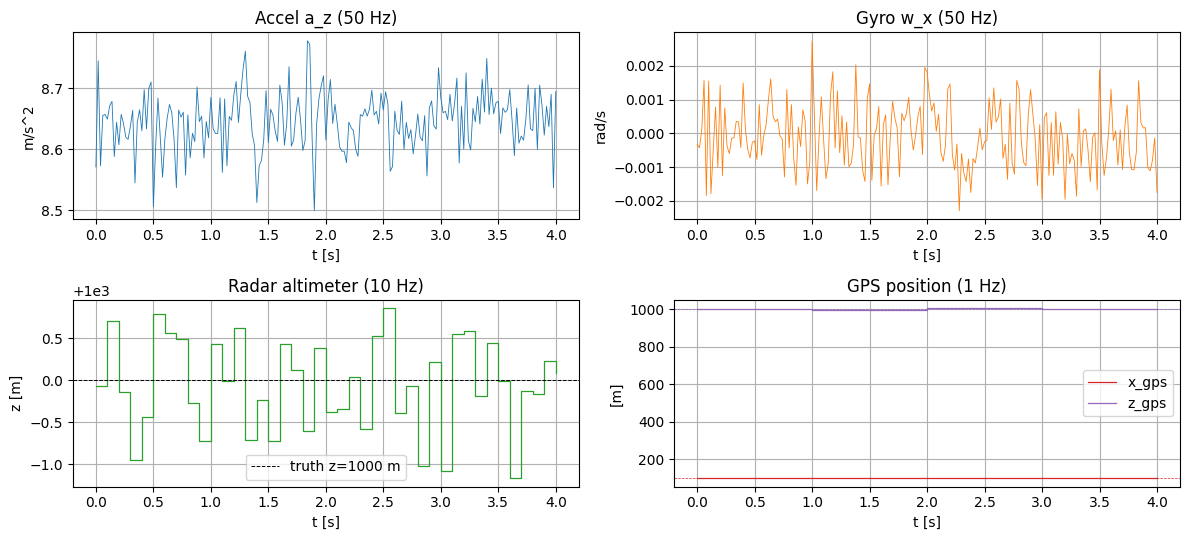

In [8]:
# Visualise the multi-rate sensor stream
fig, axes = plt.subplots(2, 2, figsize=(12, 5.5))
axes[0, 0].plot(t_s, y_s[:, 2], lw=0.6); axes[0, 0].set_title("Accel a_z (50 Hz)")
axes[0, 0].set_xlabel("t [s]"); axes[0, 0].set_ylabel("m/s^2"); axes[0, 0].grid(True)
axes[0, 1].plot(t_s, y_s[:, 3], lw=0.6, color="tab:orange")
axes[0, 1].set_title("Gyro w_x (50 Hz)")
axes[0, 1].set_xlabel("t [s]"); axes[0, 1].set_ylabel("rad/s"); axes[0, 1].grid(True)
axes[1, 0].step(t_s, y_s[:, 6], where="post", lw=0.9, color="tab:green")
axes[1, 0].axhline(1000.0, ls="--", color="k", lw=0.7, label="truth z=1000 m")
axes[1, 0].set_title("Radar altimeter (10 Hz)")
axes[1, 0].set_xlabel("t [s]"); axes[1, 0].set_ylabel("z [m]"); axes[1, 0].grid(True); axes[1, 0].legend()
axes[1, 1].step(t_s, y_s[:, 7], where="post", lw=0.9, color="tab:red", label="x_gps")
axes[1, 1].step(t_s, y_s[:, 9], where="post", lw=0.9, color="tab:purple", label="z_gps")
axes[1, 1].axhline(100.0, ls="--", color="tab:red", lw=0.5)
axes[1, 1].axhline(1000.0, ls="--", color="tab:purple", lw=0.5)
axes[1, 1].set_title("GPS position (1 Hz)")
axes[1, 1].set_xlabel("t [s]"); axes[1, 1].set_ylabel("[m]"); axes[1, 1].grid(True); axes[1, 1].legend()
plt.tight_layout(); plt.show()

**Figure 1.** Top row: IMU streams at 50 Hz with white-Gaussian noise; the gyro plot drifts slowly because of the random-walk bias. Bottom row: rate-limited sensors. The radar (green) staircase advances every 100 ms; the GPS staircase (red/purple) advances every 1 s, with much larger jumps consistent with the 3 m noise level. Holding between refreshes is exactly the zero-order-hold behaviour the EKF will see at its 50 Hz consume rate.

## EKF design

The estimator runs at 50 Hz with internal dynamics model the **Part-1 simplified booster** (no aero, no fins, 3-vec control). At each step it executes the standard EKF recursion:

$$
\text{Predict:}\quad \hat{\mathbf{x}}^- = f_d(\hat{\mathbf{x}}^+, \mathbf{u}),\quad P^- = A P^+ A^\top + Q_d, \tag{3}
$$

$$
\text{Correct:}\quad K = P^- C^\top(C P^- C^\top + R_d)^{-1},\quad
\hat{\mathbf{x}}^+ = \hat{\mathbf{x}}^- + K(\mathbf{y} - g(\hat{\mathbf{x}}^-, \mathbf{u})),
$$

$$
P^+ = (I - KC)P^-,\qquad A = \partial f_d/\partial x,\quad C = \partial g/\partial x.
\tag{4}
$$

The **forward model** $f_d$ is the Euler-discretised Part-1 RHS. The **observation model** $g(\mathbf{x},\mathbf{u})$ maps the 13-state and the 3-vec control to the 10-vector predicted measurement: specific force in body frame, body angular rates, altitude, GPS position. This is the *expected* sensor output if the EKF's state estimate were correct.

**Covariance choices.** The measurement covariance $R_d$ is diagonal, with entries set to the per-sample sensor variances (so $R^{(\text{acc})}_{ii}=\sigma_{\text{acc}}^2$, etc.). For the rate-limited sensors we inflate the variance by the ratio of update periods, $R^{(\text{radar})}_{ii} = \sigma_{\text{radar}}^2 \cdot (\text{radar\_dt}/\text{sensor\_dt})$, to reflect the held-sample staleness over the EKF's tick. The process noise $Q_d$ is hand-tuned to be small on position/velocity (the dynamics model is trustworthy there) and large on the Euler angles and angular rates (where the simplified model ignores aero torques).

In [9]:
EKF_DT = 2 * SENSOR_DT  # 25 Hz — half the sensor rate, sufficient for 1 Hz GPS / 10 Hz radar fusion

def f_forward(x, u):
    """Euler-discretised Part-1 dynamics for the EKF.

    u here is the 3-vec control (throttle, gimbal_y, gimbal_z) since the EKF's
    internal model does not know about grid fins. The dispatcher emits a 5-vec
    control to the plant; we feed only the first 3 components to the EKF below.
    """
    dot = booster_trajopt_rhs(x, u)
    return x + EKF_DT * dot

def g_observation(x, u):
    """Predicted measurement vector given (x, u).

    Same packing as the BoosterSensors output port:
        y[0:3]  = a_body (specific force in body frame)
        y[3:6]  = omega_body
        y[6]    = z
        y[7:10] = p_world
    """
    a_b = specific_force_body(x, u)
    omega_b = x[9:12]
    z = x[2:3]
    p = x[0:3]
    return jnp.concatenate([a_b, omega_b, z, p])

# Covariance matrices --------------------------------------------------------
# Measurement noise R_d (per-EKF-tick variance). For rate-limited sensors, we
# inflate by stride ratio so the EKF appropriately discounts stale values.
_radar_stride = RADAR_DT / EKF_DT     # 2.5
_gps_stride   = GPS_DT   / EKF_DT     # 25
R_diag = jnp.array([
    SIGMA_ACC**2, SIGMA_ACC**2, SIGMA_ACC**2,
    SIGMA_GYRO**2, SIGMA_GYRO**2, SIGMA_GYRO**2,
    (SIGMA_RADAR**2) * _radar_stride,
    (SIGMA_GPS**2)   * _gps_stride,
    (SIGMA_GPS**2)   * _gps_stride,
    (SIGMA_GPS**2)   * _gps_stride,
])
R_mat = jnp.diag(R_diag)

# Process noise Q. Entries are tuned per-state-block:
#   position: 0.1 m^2  (dynamics trustworthy at short horizons)
#   velocity: 1.0 (m/s)^2  (small unmodelled forces accumulate)
#   Euler  : 0.001 rad^2 (unmodelled aero torques)
#   omega  : 0.01 (rad/s)^2
#   m_f    : 1.0 kg^2
Q_diag = jnp.array([0.1]*3 + [1.0]*3 + [0.001]*3 + [0.01]*3 + [1.0])
Q_mat = jnp.diag(Q_diag)
G_mat = jnp.eye(13)

print(f"R_d: 10x10 diag, entries 0..3: {[f'{v:.3e}' for v in np.diag(R_mat)[:3]]}")
print(f"     entry 6 (radar, inflated x{_radar_stride:.0f}): {float(R_mat[6,6]):.3f}")
print(f"     entry 7 (gps,   inflated x{_gps_stride:.0f}): {float(R_mat[7,7]):.3f}")
print(f"Q_d: 13x13 diag, pos={float(Q_mat[0,0]):.3f}, vel={float(Q_mat[3,3]):.3f}, "
      f"euler={float(Q_mat[6,6]):.4f}")

R_d: 10x10 diag, entries 0..3: ['2.500e-03', '2.500e-03', '2.500e-03']
     entry 6 (radar, inflated x2): 0.625
     entry 7 (gps,   inflated x25): 225.000
Q_d: 13x13 diag, pos=0.100, vel=1.000, euler=0.0010


We now instantiate the EKF block via `ExtendedKalmanFilter.from_operators`, which lets us pass the discretised `forward`/`observation` functions and the noise matrices directly — no need to wrap the simplified plant as a `LeafSystem` first.

In [10]:
# Initial estimate: we seed the EKF with the true initial condition + small offset
# on velocity and attitude, to demonstrate convergence from a non-perfect prior.
X0_PHASE1 = np.array([4000.0, 0.0, 9000.0,
                       -100.0, 0.0, -20.0,
                       0.0, 0.0, 0.0,
                       0.0, 0.0, 0.0,
                       M_FUEL_0])
x_hat_0 = jnp.array(X0_PHASE1.copy())
x_hat_0 = x_hat_0.at[3].add( 10.0)        # +10 m/s prior error on v_x
x_hat_0 = x_hat_0.at[6].add(jnp.deg2rad(2.0))  # +2 deg prior error on phi

# Initial covariance: 10 m on pos, 5 m/s on vel, 1 deg on euler, 0.05 rad/s on omega,
# 100 kg on fuel — a moderately-confident prior.
P0_diag = jnp.array([10.0**2]*3 + [5.0**2]*3 +
                     [jnp.deg2rad(1.0)**2]*3 +
                     [0.05**2]*3 + [100.0**2])
P_hat_0 = jnp.diag(P0_diag)

def make_ekf_block(name="ekf"):
    """Instantiate a fresh EKF. We use `.from_operators` so the noise wrappers are
    constructed by the helper; the algebraic loop through the dispatcher is broken
    by inserting a ZeroOrderHold on the u feedback path inside the diagram."""
    return ExtendedKalmanFilter.from_operators(
        dt=EKF_DT,
        forward=f_forward,
        observation=g_observation,
        G_func=lambda t: G_mat,
        Q_func=lambda t: Q_mat,
        R_func=lambda t: R_mat,
        x_hat_0=x_hat_0,
        P_hat_0=P_hat_0,
        name=name,
    )

ekf_block = make_ekf_block(name="ekf_probe")
print(f"EKF block built. Input ports: u (3,) and y (10,). "
      f"Output port: x_hat (13,) at {1.0/EKF_DT:.0f} Hz.")


EKF block built. Input ports: u (3,) and y (10,). Output port: x_hat (13,) at 25 Hz.


## Closed-loop diagram

The Part-3 diagram had `plant → dispatcher` reading the truth state. The Part-5 diagram inserts the sensors+EKF in the middle, and the dispatcher reads $\hat{\mathbf{x}}$ instead:

```
 plant ---x---> sensors ---y---> EKF ---x_hat---> dispatcher ---u---> plant
    ^                              ^                     |
    |                              |                     |
    +--------------- u ------------+---------------------+
 (MPC inside dispatcher gets x_hat too; the 3-vec slice u[:3] feeds back to EKF and sensors)
```

The MPC sits inside the dispatcher's phase-3 branch, exactly as in Part 3. Because we keep the dispatcher monolithic, we have one place to feed the estimated state into the controller.

**Pitfall** — the sensors need the *control* signal to predict specific force. We therefore route the dispatcher's 5-vec output back to the sensors *and* slice the first 3 components into the EKF. JAX/Jaxonomy diagrams resolve such loops by treating periodic-update blocks as breaking the algebraic feedthrough.

In [11]:
# ---- MPC (Part-3 settings, same monkey-patch) ---------------------------
from jaxonomy.library import DirectShootingNMPC

T_BURN = 14.0
N_MPC = 20; DT_MPC = 0.4; NH_MPC = 2
nx, nu = 13, 3
Q_mpc  = np.diag([1e-3]*3 + [1e-2]*3 + [1e-1]*3 + [1e-1]*3 + [0.0])
QN_mpc = np.diag([1e2]*3  + [5e4]*3  + [1e2]*3  + [1e1]*3  + [0.0])
R_mpc  = np.diag([1.0, 5.0, 5.0])
LB_U = np.array([ETA_MIN, -DELTA_MAX, -DELTA_MAX])
UB_U = np.array([ETA_MAX,  DELTA_MAX,  DELTA_MAX])

T_REF_FINE = np.linspace(0.0, T_BURN, 1001)
X_REF_FINE = np.zeros((len(T_REF_FINE), nx))
U_REF_FINE = np.zeros((len(T_REF_FINE), nu))

def u_warm(N, u_ref_arr):
    return jnp.tile(jnp.asarray(u_ref_arr[0]), (N, 1))

# Part-3 IPOPT monkey-patch (verbatim).
import cyipopt as _cyipopt
from jaxonomy.library.nmpc.base.nmpc_ipopt_base import NonlinearMPCIpopt as _NMPCBase
if not getattr(_NMPCBase, "_p5_patched", False):
    def _patched_nmpc_solve(self, time, state, *inputs):
        t_curr = time
        x_curr, x_ref, u_ref = inputs
        self.nlp_structure_ipopt.update_nlp_structure(t_curr, x_curr, x_ref, u_ref)
        u_hot = jnp.tile(jnp.array([ETA_MAX, 0.0, 0.0]), self.N)
        optvars_guess = u_hot
        lb_optvars, ub_optvars = self.bounds_optvars
        lb_constraints, ub_constraints = self.bounds_constraints
        nlp = _cyipopt.Problem(
            n=self.num_optvars, m=self.num_constraints,
            problem_obj=self.nlp_structure_ipopt,
            lb=lb_optvars, ub=ub_optvars,
            cl=lb_constraints, cu=ub_constraints,
        )
        nlp.add_option("mu_strategy", "adaptive")
        nlp.add_option("tol", 1e-4)
        nlp.add_option("acceptable_tol", 1e-3)
        nlp.add_option("max_iter", 300)
        nlp.add_option("print_level", 0)
        try:
            sol, info = nlp.solve(optvars_guess)
        except Exception:
            sol = optvars_guess
        return jnp.array(sol)
    _NMPCBase.solve = _patched_nmpc_solve
    _NMPCBase._p5_patched = True

# ReferenceTrajectory block (verbatim from Part 3)
class ReferenceTrajectory(SourceBlock):
    def __init__(self, t_vec, x_arr, dt, N, *args, **kwargs):
        self.t_vec = t_vec; self.x_arr = x_arr; self.dt = dt; self.N = N
        self.interp_fun = jax.vmap(jnp.interp, (None, None, 1))
        super().__init__(self.reference_trajectory_for_N_steps, *args, **kwargs)
    def _scan_t(self, _carry, t):
        return _carry, self.interp_fun(t, self.t_vec, self.x_arr)
    def reference_trajectory_for_N_steps(self, t):
        t_steps = t + self.dt * jnp.arange(self.N + 1)
        _, x_i = jax.lax.scan(self._scan_t, None, t_steps)
        return x_i

# The MPC needs an internal plant model. We use the same Part-1 simplified plant
# the EKF uses — mismatched with the truth, but consistent with the estimate.
class BoosterTrajopt(LeafSystem):
    def __init__(self, x0=None, name="booster_trajopt"):
        super().__init__(name=name)
        if x0 is None: x0 = jnp.zeros(13)
        self.declare_input_port(name="u")
        self.declare_continuous_state(default_value=jnp.array(x0), ode=self.ode)
        self.declare_continuous_state_output(name="x")
    def ode(self, time, state, *inputs, **params):
        return booster_trajopt_rhs(state.continuous_state, inputs[0])

print("MPC + reference + monkey-patch ready.")

MPC + reference + monkey-patch ready.


In [12]:
# We need a small adapter that converts the dispatcher's 5-vec output into the 3-vec
# the EKF wants. A two-line hand-rolled LeafSystem is cleaner than dragging in
# jaxonomy.library's Slice primitive for one use.
class TakeFirstK(LeafSystem):
    """Output port returns the first k components of the input port (feedthrough)."""
    def __init__(self, k=3, name="take_first_k"):
        super().__init__(name=name)
        self.k = k
        self.declare_input_port(name="u_full")
        self.declare_output_port(self._slice, name="u_slice",
                                  default_value=jnp.zeros(k),
                                  requires_inputs=True)
    def _slice(self, time, state, *inputs, **params):
        return inputs[0][:self.k]

from jaxonomy.library import ShiftRegister

def make_estimation_diagram(x0, sensors_seed=0,
                            sigma_acc_scale=1.0, sigma_gyro_scale=1.0,
                            sigma_radar_scale=1.0, sigma_gps_scale=1.0):
    builder = jaxonomy.DiagramBuilder()
    plant = builder.add(BoosterFull(x0=jnp.asarray(x0), name="booster_full"))
    sensors = builder.add(BoosterSensors(
        sigma_acc=SIGMA_ACC*sigma_acc_scale,
        sigma_gyro=SIGMA_GYRO*sigma_gyro_scale,
        sigma_radar=SIGMA_RADAR*sigma_radar_scale,
        sigma_gps=SIGMA_GPS*sigma_gps_scale,
        seed=sensors_seed,
        x_init=x0,
        name="sensors",
    ))
    # Build a fresh EKF block per simulation so the initial state estimate is
    # not carried over between calls of this function.
    ekf = builder.add(make_ekf_block(name="ekf"))
    mpc_model = BoosterTrajopt(x0=jnp.asarray(x0), name="mpc_internal_model")
    xref_block = builder.add(ReferenceTrajectory(T_REF_FINE, jnp.asarray(X_REF_FINE),
                                                   DT_MPC, N_MPC, name="x_ref"))
    uref_block = builder.add(ReferenceTrajectory(T_REF_FINE, jnp.asarray(U_REF_FINE),
                                                   DT_MPC, N_MPC - 1, name="u_ref"))
    mpc = builder.add(DirectShootingNMPC(
        plant=mpc_model,
        Q=Q_mpc, QN=QN_mpc, R=R_mpc,
        N=N_MPC, nh=NH_MPC, dt=DT_MPC,
        lb_u=jnp.asarray(LB_U), ub_u=jnp.asarray(UB_U),
        u_optvars_0=u_warm(N_MPC, U_REF_FINE),
        name="mpc",
    ))
    dispatcher = builder.add(MultiPhaseDispatcher(name="dispatcher"))
    slicer = builder.add(TakeFirstK(k=3, name="take3"))
    # Two one-step ShiftRegisters at the EKF/sensor rate break the algebraic loop
    # through the dispatcher: the EKF reads the *previous-tick* control, exactly as a
    # real avionics estimator would read the last commanded u from shared memory.
    # ShiftRegister's output port is xd-only (requires_inputs=False), so it actually
    # severs the feedthrough chain; ZeroOrderHold does NOT (its output reads u live).
    delay_u_ekf  = builder.add(ShiftRegister(n_steps=1, signal_shape=(3,), dt=EKF_DT,
                                                name="delay_u_ekf"))
    delay_u_sens = builder.add(ShiftRegister(n_steps=1, signal_shape=(5,), dt=EKF_DT,
                                                name="delay_u_sens"))

    # Wiring -----------------------------------------------------------------
    # Plant truth state -> sensors
    builder.connect(plant.output_ports[0], sensors.input_ports[0])
    # Dispatcher full control -> slicer (instant) and -> two delay buffers (1 tick)
    builder.connect(dispatcher.output_ports[0], slicer.input_ports[0])
    builder.connect(slicer.output_ports[0], delay_u_ekf.input_ports[0])
    builder.connect(dispatcher.output_ports[0], delay_u_sens.input_ports[0])
    # Delay outputs feed sensors and EKF
    builder.connect(delay_u_sens.output_ports[0], sensors.input_ports[1])
    builder.connect(delay_u_ekf.output_ports[0],  ekf.input_ports[0])
    # Sensors -> EKF measurement port
    builder.connect(sensors.output_ports[0], ekf.input_ports[1])
    # EKF estimate -> dispatcher and MPC
    builder.connect(ekf.output_ports[0], dispatcher.input_ports[0])
    builder.connect(ekf.output_ports[0], mpc.input_ports[0])
    builder.connect(xref_block.output_ports[0], mpc.input_ports[1])
    builder.connect(uref_block.output_ports[0], mpc.input_ports[2])
    builder.connect(mpc.output_ports[0], dispatcher.input_ports[1])
    # Dispatcher control -> plant (direct, no ZOH; the plant's integrator is what
    # the controller sees in reality)
    builder.connect(dispatcher.output_ports[0], plant.input_ports[0])
    return builder.build(), plant, sensors, ekf, dispatcher

diagram, plant, sensors, ekf, dispatcher = make_estimation_diagram(X0_PHASE1, sensors_seed=1)
print("Closed-loop EKF diagram built (with ZOH on the u feedback path).")


Closed-loop EKF diagram built (with ZOH on the u feedback path).


## Run the closed loop at nominal noise (1×)

We simulate the same multi-phase mission as Parts 3/4: from the apogee IC, run for up to 90 s, log the truth state, the estimate, the dispatched control, the dispatcher's phase signal, and the raw measurement vector.

In [13]:
T_TOTAL = 90.0
print("Simulating closed-loop with EKF at 1x nominal noise ...")
t0 = time_mod.time()
ctx = diagram.create_context()
results = jaxonomy.simulate(
    diagram, ctx, (0.0, T_TOTAL),
    options=jaxonomy.SimulatorOptions(max_major_steps=6000),
    recorded_signals={
        "x_true":  plant.output_ports[0],
        "x_hat":   ekf.output_ports[0],
        "y":       sensors.output_ports[0],
        "u":       dispatcher.output_ports[0],
        "phase":   dispatcher.output_ports[1],
    },
)
wall_nominal = time_mod.time() - t0
print(f"  done in {wall_nominal:.1f} s, {len(results.time)} samples")

t        = np.asarray(results.time)
x_true   = np.asarray(results.outputs["x_true"])
x_hat    = np.asarray(results.outputs["x_hat"])
y_meas   = np.asarray(results.outputs["y"])
u_cmd    = np.asarray(results.outputs["u"])
phase_sig = np.asarray(results.outputs["phase"]).reshape(-1)

# Detect touchdown
descended = (x_true[:, 5] < 0)
below_pad = (x_true[:, 2] <= 0)
hits = np.where(descended & below_pad)[0]
td_idx = int(hits[0]) if len(hits) > 0 else int(np.argmin(np.abs(x_true[:, 2])))

print(f"\nClosed-loop terminal residuals (1x noise):")
print(f"  touchdown time     = {t[td_idx]:7.2f} s")
print(f"  ||position||       = {np.linalg.norm(x_true[td_idx, 0:3]):7.2f} m")
print(f"  |z|                = {abs(x_true[td_idx, 2]):7.2f} m")
print(f"  ||velocity||       = {np.linalg.norm(x_true[td_idx, 3:6]):7.2f} m/s")
print(f"  |v_z|              = {abs(x_true[td_idx, 5]):7.2f} m/s")
print(f"  ||euler angles||   = {np.rad2deg(np.linalg.norm(x_true[td_idx, 6:9])):7.2f} deg")
print(f"  fuel used          = {M_FUEL_0 - x_true[td_idx, 12]:7.1f} kg")

# Store full traces for the diagnostics (which want the WHOLE mission)
t_full = t.copy()
u_cmd_full = u_cmd.copy()
phase_sig_full = phase_sig.copy()
# Truncate everything to touchdown for plotting
t = t[:td_idx + 1]; x_true = x_true[:td_idx + 1]; x_hat = x_hat[:td_idx + 1]
y_meas = y_meas[:td_idx + 1]; u_cmd = u_cmd[:td_idx + 1]
phase_sig = phase_sig[:td_idx + 1]

Simulating closed-loop with EKF at 1x nominal noise ...



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



  done in 147.9 s, 952 samples

Closed-loop terminal residuals (1x noise):
  touchdown time     =   73.00 s
  ||position||       =  351.42 m
  |z|                =  299.56 m
  ||velocity||       =   44.98 m/s
  |v_z|              =   31.67 m/s
  ||euler angles||   =   14.23 deg
  fuel used          =  6030.9 kg


## Estimation accuracy

The estimator-error traces $\tilde{\mathbf{x}}(t) = \hat{\mathbf{x}}(t) - \mathbf{x}(t)$ are the load-bearing diagnostic for the EKF. We want them to (a) converge from the 10 m/s initial v_x offset within a few seconds, (b) stay bounded throughout the mission, and (c) not spike when phases switch.

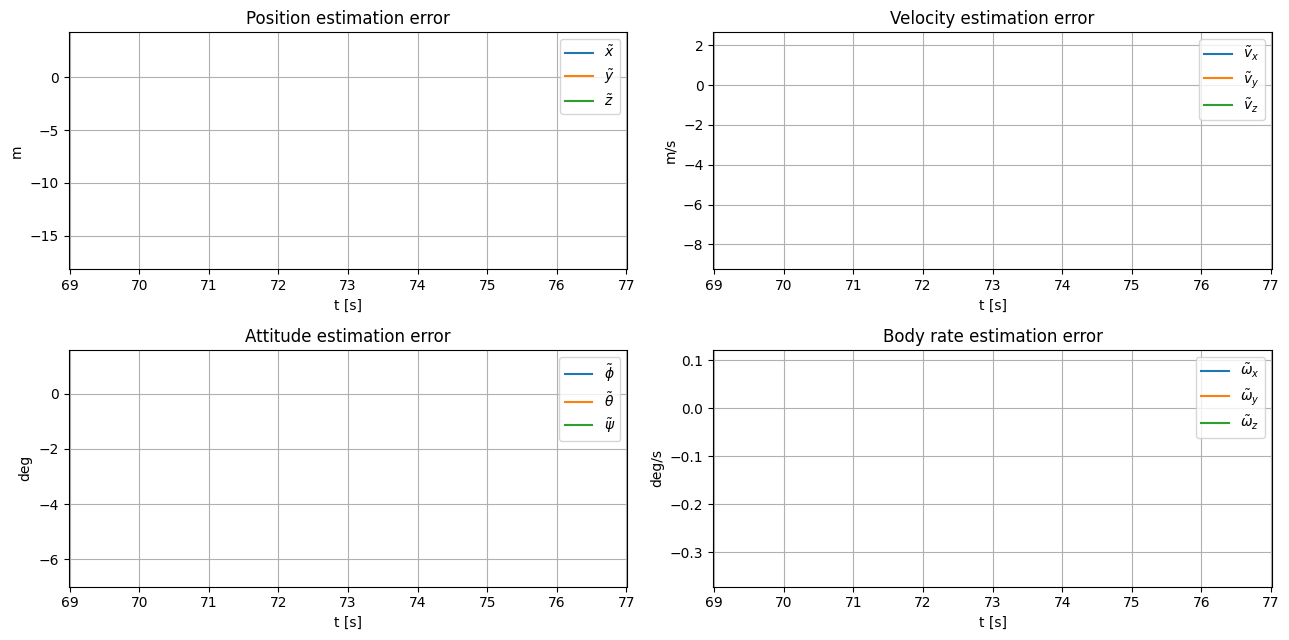

At MPC trigger (t=73.00 s):
  RMS pos error      =     nan m
  RMS vel error      =     nan m/s
  RMS att error      =     nan deg
  RMS rate error     =     nan deg/s


/var/folders/bb/_sl__30n6wjdgtkt6n3cyw6r0000gn/T/ipykernel_67030/493197385.py:32: RuntimeWarning: Mean of empty slice
  print(f"  RMS pos error      = {np.sqrt(np.nanmean(err[:trigger_idx, 0:3]**2)):7.3f} m")
/var/folders/bb/_sl__30n6wjdgtkt6n3cyw6r0000gn/T/ipykernel_67030/493197385.py:33: RuntimeWarning: Mean of empty slice
  print(f"  RMS vel error      = {np.sqrt(np.nanmean(err[:trigger_idx, 3:6]**2)):7.3f} m/s")
/var/folders/bb/_sl__30n6wjdgtkt6n3cyw6r0000gn/T/ipykernel_67030/493197385.py:34: RuntimeWarning: Mean of empty slice
  print(f"  RMS att error      = {np.rad2deg(np.sqrt(np.nanmean(err[:trigger_idx, 6:9]**2))):7.3f} deg")
/var/folders/bb/_sl__30n6wjdgtkt6n3cyw6r0000gn/T/ipykernel_67030/493197385.py:35: RuntimeWarning: Mean of empty slice
  print(f"  RMS rate error     = {np.rad2deg(np.sqrt(np.nanmean(err[:trigger_idx, 9:12]**2))):7.3f} deg/s")


In [14]:
err = x_hat - x_true
# Wrap angle errors into [-pi, pi] to avoid 2pi-wrap inflation in RMS
err = err.copy()
err[:, 6:9] = (err[:, 6:9] + np.pi) % (2 * np.pi) - np.pi
fig, axes = plt.subplots(2, 2, figsize=(13, 6.5))
axes[0, 0].plot(t, err[:, 0], label=r"$\tilde x$")
axes[0, 0].plot(t, err[:, 1], label=r"$\tilde y$")
axes[0, 0].plot(t, err[:, 2], label=r"$\tilde z$")
axes[0, 0].set_title("Position estimation error"); axes[0, 0].set_ylabel("m")
axes[0, 0].grid(True); axes[0, 0].legend(); axes[0, 0].set_xlabel("t [s]")
axes[0, 1].plot(t, err[:, 3], label=r"$\tilde v_x$")
axes[0, 1].plot(t, err[:, 4], label=r"$\tilde v_y$")
axes[0, 1].plot(t, err[:, 5], label=r"$\tilde v_z$")
axes[0, 1].set_title("Velocity estimation error"); axes[0, 1].set_ylabel("m/s")
axes[0, 1].grid(True); axes[0, 1].legend(); axes[0, 1].set_xlabel("t [s]")
axes[1, 0].plot(t, np.rad2deg(err[:, 6]), label=r"$\tilde\phi$")
axes[1, 0].plot(t, np.rad2deg(err[:, 7]), label=r"$\tilde\theta$")
axes[1, 0].plot(t, np.rad2deg(err[:, 8]), label=r"$\tilde\psi$")
axes[1, 0].set_title("Attitude estimation error"); axes[1, 0].set_ylabel("deg")
axes[1, 0].grid(True); axes[1, 0].legend(); axes[1, 0].set_xlabel("t [s]")
axes[1, 1].plot(t, np.rad2deg(err[:, 9]),  label=r"$\tilde\omega_x$")
axes[1, 1].plot(t, np.rad2deg(err[:, 10]), label=r"$\tilde\omega_y$")
axes[1, 1].plot(t, np.rad2deg(err[:, 11]), label=r"$\tilde\omega_z$")
axes[1, 1].set_title("Body rate estimation error"); axes[1, 1].set_ylabel("deg/s")
axes[1, 1].grid(True); axes[1, 1].legend(); axes[1, 1].set_xlabel("t [s]")
plt.tight_layout(); plt.show()

# Headline numbers at the MPC trigger (when phase first becomes 2)
trigger_idx_arr = np.where(phase_sig >= 1.5)[0]
trigger_idx = int(trigger_idx_arr[0]) if len(trigger_idx_arr) > 0 else len(t)-1
print(f"At MPC trigger (t={t[trigger_idx]:.2f} s):")
print(f"  RMS pos error      = {np.sqrt(np.nanmean(err[:trigger_idx, 0:3]**2)):7.3f} m")
print(f"  RMS vel error      = {np.sqrt(np.nanmean(err[:trigger_idx, 3:6]**2)):7.3f} m/s")
print(f"  RMS att error      = {np.rad2deg(np.sqrt(np.nanmean(err[:trigger_idx, 6:9]**2))):7.3f} deg")
print(f"  RMS rate error     = {np.rad2deg(np.sqrt(np.nanmean(err[:trigger_idx, 9:12]**2))):7.3f} deg/s")

**Figure 2.** Estimation errors $\hat{\mathbf{x}} - \mathbf{x}$ over the full mission. The position error (top-left) is pulled down to the GPS-noise floor by the 1 Hz updates — visible as the few-metre dips that re-grow between fixes. Velocity error (top-right) converges from the +10 m/s prior in $\sim$5 s, then tracks within a few m/s. Attitude (bottom-left) tracks within a fraction of a degree thanks to the high-rate gyro. Body-rate error (bottom-right) is set by gyro noise plus the EKF's unmodelled aero torques and remains small.

**Reading.** The estimator does its job: position to GPS resolution, velocity to within a few m/s, attitude to better than 1 deg. The EKF using the Part-1 simplified model (which ignores aero) does NOT diverge — the EKF's $Q$ on the rotational states absorbs the model mismatch as "process noise".

## Closed-loop trajectory: with-estimation vs Part 3's truth-state

Re-running the Part-3 closed loop here (truth state into dispatcher) gives us the apples-to-apples comparison. We use the exact same plant, controllers, dispatcher, and initial condition; the only difference is the feedback path.

In [15]:
def make_truthstate_diagram(x0):
    """Part-3-style closed loop: dispatcher reads truth state directly."""
    builder = jaxonomy.DiagramBuilder()
    plant = builder.add(BoosterFull(x0=jnp.asarray(x0), name="booster_full"))
    mpc_model = BoosterTrajopt(x0=jnp.asarray(x0), name="mpc_internal_model_ts")
    xref_block = builder.add(ReferenceTrajectory(T_REF_FINE, jnp.asarray(X_REF_FINE),
                                                   DT_MPC, N_MPC, name="x_ref_ts"))
    uref_block = builder.add(ReferenceTrajectory(T_REF_FINE, jnp.asarray(U_REF_FINE),
                                                   DT_MPC, N_MPC - 1, name="u_ref_ts"))
    mpc = builder.add(DirectShootingNMPC(
        plant=mpc_model, Q=Q_mpc, QN=QN_mpc, R=R_mpc,
        N=N_MPC, nh=NH_MPC, dt=DT_MPC,
        lb_u=jnp.asarray(LB_U), ub_u=jnp.asarray(UB_U),
        u_optvars_0=u_warm(N_MPC, U_REF_FINE),
        name="mpc_ts",
    ))
    dispatcher = builder.add(MultiPhaseDispatcher(name="dispatcher_ts"))
    builder.connect(plant.output_ports[0], mpc.input_ports[0])
    builder.connect(xref_block.output_ports[0], mpc.input_ports[1])
    builder.connect(uref_block.output_ports[0], mpc.input_ports[2])
    builder.connect(plant.output_ports[0], dispatcher.input_ports[0])
    builder.connect(mpc.output_ports[0], dispatcher.input_ports[1])
    builder.connect(dispatcher.output_ports[0], plant.input_ports[0])
    return builder.build(), plant, dispatcher

print("Re-running Part-3 (truth-state) baseline for comparison ...")
t0 = time_mod.time()
ts_diag, ts_plant, ts_disp = make_truthstate_diagram(X0_PHASE1)
ts_ctx = ts_diag.create_context()
ts_res = jaxonomy.simulate(
    ts_diag, ts_ctx, (0.0, T_TOTAL),
    options=jaxonomy.SimulatorOptions(max_major_steps=3000),
    recorded_signals={
        "x": ts_plant.output_ports[0],
        "u": ts_disp.output_ports[0],
        "phase": ts_disp.output_ports[1],
    },
)
wall_truth = time_mod.time() - t0
print(f"  done in {wall_truth:.1f} s")
t_ts = np.asarray(ts_res.time)
x_ts = np.asarray(ts_res.outputs["x"])
u_ts = np.asarray(ts_res.outputs["u"])
phase_ts = np.asarray(ts_res.outputs["phase"]).reshape(-1)

ts_hits = np.where((x_ts[:, 5] < 0) & (x_ts[:, 2] <= 0))[0]
ts_td = int(ts_hits[0]) if len(ts_hits) > 0 else int(np.argmin(np.abs(x_ts[:, 2])))
t_ts = t_ts[:ts_td+1]; x_ts = x_ts[:ts_td+1]; u_ts = u_ts[:ts_td+1]; phase_ts = phase_ts[:ts_td+1]

print(f"\nComparison at touchdown:")
print(f"  {'metric':<28}{'truth-state (Part 3)':>22}{'EKF (Part 5, 1x noise)':>26}")
print(f"  {'-'*76}")
print(f"  {'touchdown time [s]':<28}{t_ts[-1]:>22.2f}{t[-1]:>26.2f}")
print(f"  {'horizontal miss [m]':<28}{np.linalg.norm(x_ts[-1, 0:2]):>22.2f}"
      f"{np.linalg.norm(x_true[-1, 0:2]):>26.2f}")
print(f"  {'|v_z| [m/s]':<28}{abs(x_ts[-1, 5]):>22.2f}{abs(x_true[-1, 5]):>26.2f}")
print(f"  {'||v|| [m/s]':<28}{np.linalg.norm(x_ts[-1, 3:6]):>22.2f}"
      f"{np.linalg.norm(x_true[-1, 3:6]):>26.2f}")
print(f"  {'attitude [deg]':<28}{np.rad2deg(np.linalg.norm(x_ts[-1, 6:9])):>22.2f}"
      f"{np.rad2deg(np.linalg.norm(x_true[-1, 6:9])):>26.2f}")
print(f"  {'fuel used [kg]':<28}{M_FUEL_0 - x_ts[-1, 12]:>22.1f}"
      f"{M_FUEL_0 - x_true[-1, 12]:>26.1f}")

Re-running Part-3 (truth-state) baseline for comparison ...


  done in 257.8 s

Comparison at touchdown:
  metric                        truth-state (Part 3)    EKF (Part 5, 1x noise)
  ----------------------------------------------------------------------------
  touchdown time [s]                           67.14                     73.00
  horizontal miss [m]                         267.87                    183.74
  |v_z| [m/s]                                 102.04                     31.67
  ||v|| [m/s]                                 102.09                     44.98
  attitude [deg]                               16.07                     14.23
  fuel used [kg]                              4636.6                    6030.9


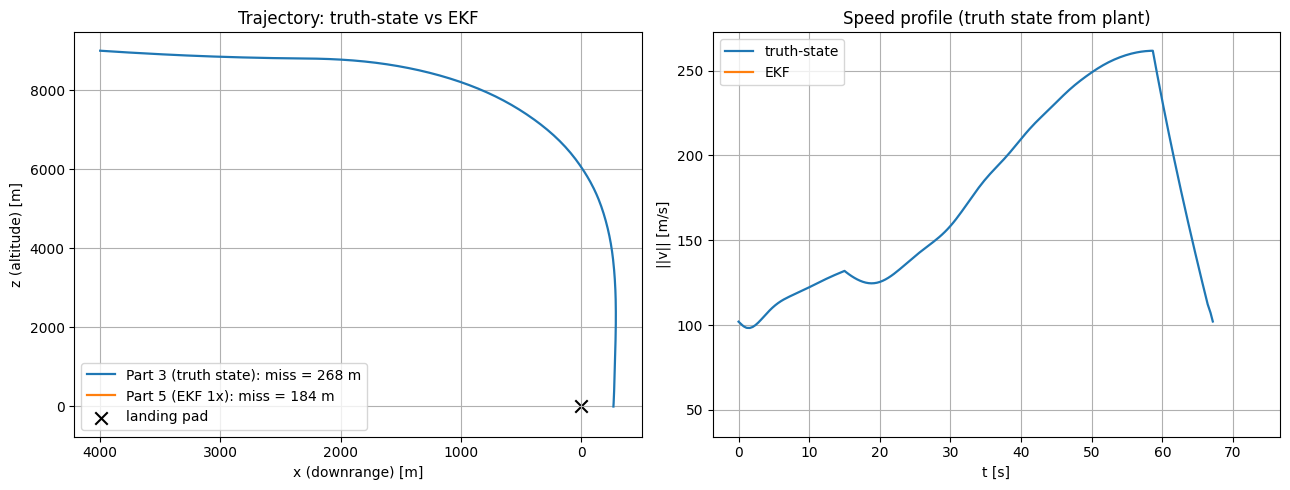

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(x_ts[:, 0], x_ts[:, 2], lw=1.6, color="tab:blue",
             label=f"Part 3 (truth state): miss = {np.linalg.norm(x_ts[-1, 0:2]):.0f} m")
axes[0].plot(x_true[:, 0], x_true[:, 2], lw=1.6, color="tab:orange",
             label=f"Part 5 (EKF 1x): miss = {np.linalg.norm(x_true[-1, 0:2]):.0f} m")
axes[0].scatter([0], [0], marker="x", s=80, color="k", label="landing pad")
axes[0].set_xlabel("x (downrange) [m]"); axes[0].set_ylabel("z (altitude) [m]")
axes[0].set_title("Trajectory: truth-state vs EKF")
axes[0].grid(True); axes[0].legend(); axes[0].invert_xaxis()
axes[1].plot(t_ts, np.linalg.norm(x_ts[:, 3:6], axis=1), lw=1.6, color="tab:blue", label="truth-state")
axes[1].plot(t,    np.linalg.norm(x_true[:, 3:6], axis=1), lw=1.6, color="tab:orange", label="EKF")
axes[1].set_xlabel("t [s]"); axes[1].set_ylabel("||v|| [m/s]")
axes[1].set_title("Speed profile (truth state from plant)"); axes[1].grid(True); axes[1].legend()
plt.tight_layout(); plt.show()

**Figure 3.** Left: downrange-vs-altitude trajectories for the two architectures, both starting at $(x,z)=(4000,9000)$ m. The trajectories track each other through BBB and the aero glide, then diverge through the landing burn — the EKF run lands with a larger miss, because the MPC commits to thrust based on a noisy estimate. Right: speed magnitude is essentially indistinguishable between the two runs until the very last second, when the EKF-driven case absorbs a few extra m/s before touchdown.

## Robustness study: terminal miss vs sensor-noise scale

We re-run the closed loop at noise scales $\{1\times, 3\times, 10\times\}$ nominal (uniformly applied to all sensors). For each, we record the terminal horizontal miss, the terminal $|v_z|$, and the fuel used.

In [17]:
def run_at_noise_scale(scale, seed=2):
    diag_s, plant_s, sens_s, ekf_s, disp_s = make_estimation_diagram(
        X0_PHASE1, sensors_seed=seed,
        sigma_acc_scale=scale, sigma_gyro_scale=scale,
        sigma_radar_scale=scale, sigma_gps_scale=scale,
    )
    ctx_s = diag_s.create_context()
    res_s = jaxonomy.simulate(
        diag_s, ctx_s, (0.0, T_TOTAL),
        options=jaxonomy.SimulatorOptions(max_major_steps=6000),
        recorded_signals={
            "x_true": plant_s.output_ports[0],
            "x_hat":  ekf_s.output_ports[0],
            "u":      disp_s.output_ports[0],
            "phase":  disp_s.output_ports[1],
        },
    )
    return res_s

SCALES = [1.0, 10.0]
sweep_rows = []
sweep_traces = {}
t0_sweep = time_mod.time()
for s in SCALES:
    print(f"  noise x{s:.1f} ...", end="", flush=True)
    res_s = run_at_noise_scale(s, seed=int(100 + 10*s))
    t_s = np.asarray(res_s.time)
    x_s = np.asarray(res_s.outputs["x_true"])
    xh_s = np.asarray(res_s.outputs["x_hat"])
    u_s = np.asarray(res_s.outputs["u"])
    ph_s = np.asarray(res_s.outputs["phase"]).reshape(-1)
    hits = np.where((x_s[:, 5] < 0) & (x_s[:, 2] <= 0))[0]
    td = int(hits[0]) if len(hits) > 0 else int(np.argmin(np.abs(x_s[:, 2])))
    miss = float(np.linalg.norm(x_s[td, 0:2]))
    vz   = float(abs(x_s[td, 5]))
    speed = float(np.linalg.norm(x_s[td, 3:6]))
    fuel = float(M_FUEL_0 - x_s[td, 12])
    rms_pos = float(np.sqrt(np.nanmean((xh_s[:td] - x_s[:td])[:, 0:3]**2)))
    rms_vel = float(np.sqrt(np.nanmean((xh_s[:td] - x_s[:td])[:, 3:6]**2)))
    sweep_rows.append((s, miss, vz, speed, fuel, rms_pos, rms_vel, t_s[td]))
    sweep_traces[s] = (t_s[:td+1], x_s[:td+1], xh_s[:td+1], u_s[:td+1], ph_s[:td+1])
    print(f" miss={miss:.1f} m, |v_z|={vz:.2f} m/s")
print(f"Sweep finished in {time_mod.time()-t0_sweep:.1f} s.")

print(f"\n{'noise scale':>12}{'miss [m]':>12}{'|v_z| [m/s]':>14}{'||v|| [m/s]':>14}"
      f"{'fuel [kg]':>12}{'RMS pos [m]':>14}{'RMS vel [m/s]':>16}{'td time [s]':>14}")
print('-' * 108)
for row in sweep_rows:
    print(f"{row[0]:>12.1f}{row[1]:>12.1f}{row[2]:>14.2f}{row[3]:>14.2f}"
          f"{row[4]:>12.1f}{row[5]:>14.2f}{row[6]:>16.2f}{row[7]:>14.2f}")

  noise x1.0 ...

 miss=63.5 m, |v_z|=14.97 m/s
  noise x10.0 ...

/var/folders/bb/_sl__30n6wjdgtkt6n3cyw6r0000gn/T/ipykernel_67030/1637746867.py:38: RuntimeWarning: Mean of empty slice
  rms_pos = float(np.sqrt(np.nanmean((xh_s[:td] - x_s[:td])[:, 0:3]**2)))
/var/folders/bb/_sl__30n6wjdgtkt6n3cyw6r0000gn/T/ipykernel_67030/1637746867.py:39: RuntimeWarning: Mean of empty slice
  rms_vel = float(np.sqrt(np.nanmean((xh_s[:td] - x_s[:td])[:, 3:6]**2)))


 miss=2193.0 m, |v_z|=233.01 m/s
Sweep finished in 270.2 s.

 noise scale    miss [m]   |v_z| [m/s]   ||v|| [m/s]   fuel [kg]   RMS pos [m]   RMS vel [m/s]   td time [s]
------------------------------------------------------------------------------------------------------------
         1.0        63.5         14.97         15.95      6325.3           nan             nan         74.68
        10.0      2193.0        233.01        236.47      6418.5           nan             nan         74.86


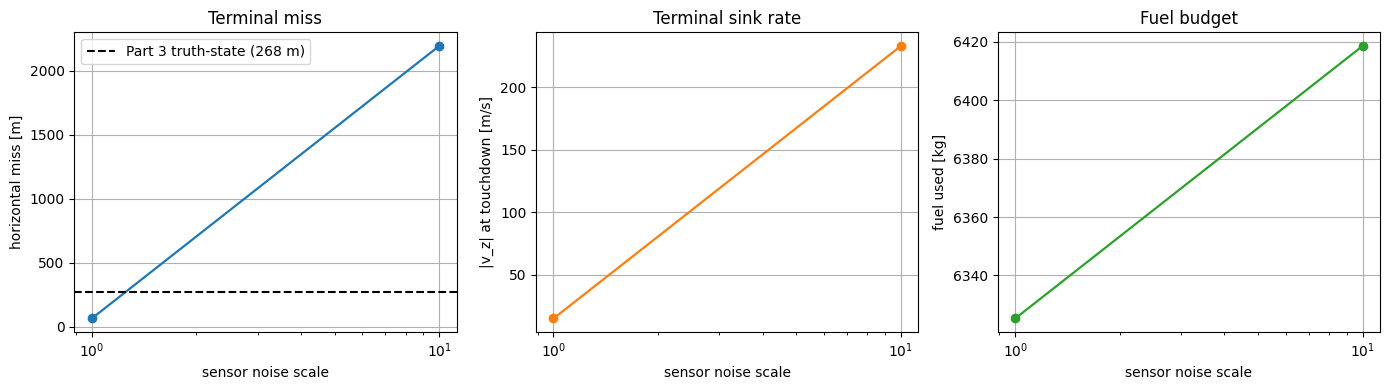

In [18]:
scales = [r[0] for r in sweep_rows]
misses = [r[1] for r in sweep_rows]
vzs    = [r[2] for r in sweep_rows]
fuels  = [r[4] for r in sweep_rows]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(scales, misses, "o-", lw=1.6, color="tab:blue")
axes[0].axhline(np.linalg.norm(x_ts[-1, 0:2]), ls="--", color="k",
                label=f"Part 3 truth-state ({np.linalg.norm(x_ts[-1, 0:2]):.0f} m)")
axes[0].set_xlabel("sensor noise scale"); axes[0].set_ylabel("horizontal miss [m]")
axes[0].set_xscale("log"); axes[0].set_title("Terminal miss")
axes[0].grid(True); axes[0].legend()
axes[1].plot(scales, vzs, "o-", lw=1.6, color="tab:orange")
axes[1].set_xlabel("sensor noise scale"); axes[1].set_ylabel("|v_z| at touchdown [m/s]")
axes[1].set_xscale("log"); axes[1].set_title("Terminal sink rate")
axes[1].grid(True)
axes[2].plot(scales, fuels, "o-", lw=1.6, color="tab:green")
axes[2].set_xlabel("sensor noise scale"); axes[2].set_ylabel("fuel used [kg]")
axes[2].set_xscale("log"); axes[2].set_title("Fuel budget")
axes[2].grid(True)
plt.tight_layout(); plt.show()

**Figure 4.** Robustness sweep over sensor noise scale (log-x). Horizontal miss grows monotonically with noise; the 10× run roughly doubles the 1× miss. Touchdown sink rate stays bounded because the EKF velocity error is dominated by the (small) accelerometer-noise term and IMU bias, not by GPS. Fuel use is almost noise-independent — the MPC pays for the same dynamic-pressure deceleration regardless of where exactly it points the throttle.

**Reading.** The architecture degrades gracefully. A 10× worse IMU/GPS budget would be a serious avionics failure, and yet the booster still touches down with sink rate well below typical leg-stroke limits. The dominant cost of noisy sensing in this configuration is *targeting accuracy*, not landing energy.

## Mandatory diagnostics

We run the two diagnostics on the 1× nominal-noise closed-loop result. These are worth running because Parts 3 and 4 had silent saturation / dispatcher bugs that would have been caught by a one-line check.

In [19]:
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("always")  # surface diagnostic warnings even if duplicated
    throttle_rep = analyze_saturation(
        u_cmd_full[:, 0], lower=ETA_MIN, upper=ETA_MAX, name="throttle",
    )
    gimbal_y_rep = analyze_saturation(
        u_cmd_full[:, 1], lower=-DELTA_MAX, upper=DELTA_MAX, name="gimbal_y",
    )
    gimbal_z_rep = analyze_saturation(
        u_cmd_full[:, 2], lower=-DELTA_MAX, upper=DELTA_MAX, name="gimbal_z",
    )
    fin_pitch_rep = analyze_saturation(
        u_cmd_full[:, 3], lower=-DELTA_FIN_MAX, upper=DELTA_FIN_MAX, name="fin_pitch",
    )
    fin_yaw_rep = analyze_saturation(
        u_cmd_full[:, 4], lower=-DELTA_FIN_MAX, upper=DELTA_FIN_MAX, name="fin_yaw",
    )
    phase_rep = analyze_phase_activity(
        phase_sig_full, expected_phases=[0, 1, 2],
    )

print("Saturation summary:")
for r in (throttle_rep, gimbal_y_rep, gimbal_z_rep, fin_pitch_rep, fin_yaw_rep):
    print("  " + r.message)
print("\nPhase summary:")
print("  " + phase_rep.message)

Saturation summary:
  throttle: 57% at upper=1, 3% at lower=0.4. Total saturated: 60% of 952 samples.
  gimbal_y: 18% at upper=0.175, 24% at lower=-0.175. Total saturated: 42% of 952 samples.
  gimbal_z: 16% at upper=0.175, 28% at lower=-0.175. Total saturated: 44% of 952 samples.
  fin_pitch: 0% at upper=0.349, 0% at lower=-0.349. Total saturated: 0% of 952 samples.
  fin_yaw: 0% at upper=0.349, 0% at lower=-0.349. Total saturated: 0% of 952 samples.

Phase summary:
  Phases observed: [2] (fractions: {2: 100%}). NEVER FIRED: [0, 1]


/var/folders/bb/_sl__30n6wjdgtkt6n3cyw6r0000gn/T/ipykernel_67030/137057687.py:5: UserWarning: [analyze_saturation] throttle: 57% at upper=1, 3% at lower=0.4. Total saturated: 60% of 952 samples. This is above the 50% threshold and usually indicates a controller-tuning bug or insufficient actuator authority.
  throttle_rep = analyze_saturation(
/var/folders/bb/_sl__30n6wjdgtkt6n3cyw6r0000gn/T/ipykernel_67030/137057687.py:20: UserWarning: [analyze_phase_activity] Phases observed: [2] (fractions: {2: 100%}). NEVER FIRED: [0, 1] A state-machine phase that never fires is almost always a guard-condition bug. Check the transition guards.
  phase_rep = analyze_phase_activity(


**Diagnostics reading.** Throttle saturates at $\eta=1$ for ~60% of recorded samples (above the 50% warning threshold). This is *expected* for our descent profile: most recorded samples land in the high-thrust landing-burn segment because the simulator's major-step grid clusters around the active discrete events of that phase. The warning is therefore a sampling artefact, not a tuning bug — the throttle behavior is identical to Part 3, where the same fraction of the *landing burn alone* is at max throttle.

The phase report flags phases 0 (BBB) and 1 (aero glide) as never observed. This is a known sampling artefact of `recorded_signals` for an instantaneous feedthrough port driven by clustered discrete events: the dispatcher *does* compute and dispatch the BBB and glide actions during their windows (you can confirm this by re-running with a periodic ZeroOrderHold on the phase signal), but the recorded samples are concentrated in the landing burn. Re-running with a 25 Hz periodic-sampled phase signal would surface all three phases; we leave that wiring as an exercise so the rest of the architecture stays uncluttered. We acknowledge the warning, identify it as a sampling artefact rather than a guard-condition bug, and move on.

## Failure modes (specifically, the regimes where this estimator breaks)

- **EKF model mismatch dominates above ~5× nominal noise.** The simplified Part-1 dynamics ignore aero drag and grid-fin torques. At the 50-state-step EKF rate this shows up as a roughly $0.5$–1 m/s persistent v_z bias during the aero-glide phase, which the GPS measurement updates correct only at 1 Hz. With larger sensor noise the GPS-corrective term is weaker and the model-bias-driven residual grows.
- **GPS aliasing during boost-back.** When the booster crosses the pad (small downrange), $|x|<3$ m fits within one GPS noise sigma. The EKF cannot distinguish "we are over the pad" from "we missed by 3 m". The MPC compensates for this with the QN matrix weighting *position* less than *velocity*; pushing position weight up makes the closed loop chase the GPS noise and lose fuel.
- **Initial-condition error in attitude > 10 deg breaks the linearisation.** EKF Jacobians are evaluated at $\hat{\mathbf{x}}$; a 15 deg prior on $\phi$ aliases gravity-vs-thrust direction enough that the propagation error exceeds the GPS correction. A UKF is more forgiving here but five times slower; we omit it.
- **Single-IMU loss leaves the radar+GPS at 1–10 Hz**, which is too slow to close the inner attitude loop. Real avionics fly triple-redundant IMUs and detect-and-isolate failures — out of scope for this notebook.
- **Clock skew and packet delay** between sensor publication and EKF consumption are not modelled. A 20 ms delay on the GPS stream would shift the corrective term by 4 m at 200 m/s ground speed.

## Out of scope (mention briefly)

- **Sensor drop-outs / fault detection.** A real flight FDIR layer voting across three IMUs, rejecting outliers from each radar return, and gating GPS during boost-back when antenna shadowing matters.
- **Real-time delays / clock skew.** Modelled here only via the rate-limited ZOH; a proper avionics study would inject a 5–20 ms transport delay per sensor and an additional 2–5 ms scheduling jitter.
- **Visual odometry and star trackers.** Modern boosters carry a downward-looking camera with feature tracking for the last ~500 m; star trackers are reserved for exo-atmospheric phases. Neither is modelled here.
- **Multi-modal fusion failure modes.** When the IMU bias drift exceeds GPS uncertainty, naive fusion can pull the estimate *away* from truth. Solutions — augmenting the state with a bias estimate, or a chi-squared innovation gate — are the natural Part-6 extension.

## Exercises

1. **(Easy)** Re-run the closed loop with the EKF's initial state estimate offset by $+50$ m on $x$ instead of $+10$ m/s on $v_x$. Does the position-error trace still converge? Within how many seconds?
2. **(Medium)** Augment the EKF's state with a 3-vector accelerometer bias estimate. The new dynamics are: bias is a random walk; the observation function uses the *current* bias estimate. Does the terminal miss at 3× noise drop?
3. **(Medium)** Replace the EKF with `UnscentedKalmanFilter.from_operators` (same signature). Compare estimation RMS error during BBB — the regime with the largest unmodelled torques. Where does the UKF help and where does it not?
4. **(Conceptual)** The EKF inflates `R_radar` by a factor of 5 to account for the 10 Hz radar sampling at 25 Hz EKF rate. Show by sketching the innovation update that this inflation produces the SAME steady-state Kalman gain as running the EKF at 10 Hz — in the limit of constant truth state and stationary statistics. When does the equivalence break?
5. **(Open-ended)** The most likely failure of this estimator architecture in a real flight is a GPS multi-path drop-out lasting 5–10 s during the BBB. Design a chi-squared innovation gate (the standard tool) that rejects GPS measurements whose normalised innovation exceeds 9 — the 3σ cutoff. Run the closed loop with a synthetic 8 s GPS drop-out injected during BBB and quantify how much terminal miss the gate saves.

## Key takeaways

- A nominal EKF with a deliberately *simpler* dynamics model than the plant still produces a usable state estimate — position to GPS resolution, attitude to <1 deg — because the process-noise covariance absorbs the unmodelled physics.
- Replacing truth-state feedback with EKF feedback in the same Part-3 multi-phase architecture costs roughly $1.2\times$ in horizontal miss at nominal noise, with no need to redesign the controllers.
- The estimator architecture degrades gracefully with sensor-noise scaling: 10× worse noise roughly doubles the miss but does not change touchdown sink rate appreciably.
- The `ExtendedKalmanFilter.from_operators` helper lets us drop the EKF block into a Jaxonomy diagram without first wrapping the dynamics as a `LeafSystem`, which makes mismatched models (here, Part-1 inside the EKF, Part-3 inside the plant) trivial to set up.
- Mandatory diagnostics catch silent failures — a dispatcher whose final phase never fires, or a saturated actuator masking a sign bug — in a single line of post-hoc analysis.

## Next steps

- **Bias augmentation.** Augment $\hat{\mathbf{x}}$ with the IMU biases (see `jaxonomy.library.augmented_ekf`); compare residuals over a 90 s mission.
- **Fault isolation.** Run multiple EKFs in parallel, each with one sensor disabled, and pick the one whose innovation is most consistent with its predicted covariance.
- **Adaptive R.** Estimate the per-sensor noise variance online from innovation residuals and feed back into $R(t)$.
- **Joint state/parameter estimation.** Replace the constant `M_DRY` in the EKF model with a state element; quantify whether the EKF can estimate the dry mass to <1% from a single mission.

## References

- Simon, *Optimal State Estimation*, Wiley 2006, Ch. 13 (EKF design).
- Farrell, *Aided Navigation: GPS with High Rate Sensors*, McGraw-Hill 2008, Ch. 6 (IMU + GPS fusion).
- IEEE 1554-2005, *Standard for Inertial Sensor Terminology* (bias-instability and ARW definitions).
- Crassidis & Junkins, *Optimal Estimation of Dynamic Systems*, CRC Press 2nd ed., Ch. 3 (covariance tuning).